<a href="https://colab.research.google.com/github/mannatdhull124/Handwritten-Digit-Classification-using-LDA-and-Logistic-Regression/blob/main/Handwritten_Digit_Classification_using_LDA_and_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Digit Classification using LDA and Logistic Regression

## 📌 Problem Statement

Handwritten digit recognition is an important application of Machine Learning and pattern recognition systems. The objective of this project is to classify handwritten digit images into their respective classes ranging from 0 to 9 using Machine Learning techniques.

The dataset contains pixel-based image features, which create a high-dimensional feature space. Handling high-dimensional data can increase computational complexity and affect classification performance. Therefore, dimensionality reduction techniques are required to simplify the dataset while preserving important information.

This project aims to apply Linear Discriminant Analysis (LDA) for dimensionality reduction and Logistic Regression for multiclass classification. The goal is to build an efficient and accurate classification model capable of recognizing handwritten digits effectively.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import *
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [3]:
dataset = load_digits()

In [46]:
dataset

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [47]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [4]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)

In [5]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [6]:
df['Target'] = dataset.target

In [7]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [8]:
df['Target'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [9]:
df['Target'].value_counts()

,count
Target,
3,183
1,182
5,182
4,181
6,181
9,180
7,179
0,178
2,177


In [10]:
df.isnull().sum()

,0
pixel_0_0,0
pixel_0_1,0
pixel_0_2,0
pixel_0_3,0
pixel_0_4,0
...,...
pixel_7_4,0
pixel_7_5,0
pixel_7_6,0
pixel_7_7,0


In [11]:
df.duplicated().sum()

np.int64(0)

<Figure size 640x480 with 0 Axes>

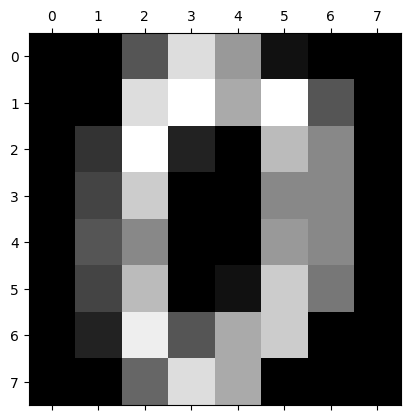

<Figure size 640x480 with 0 Axes>

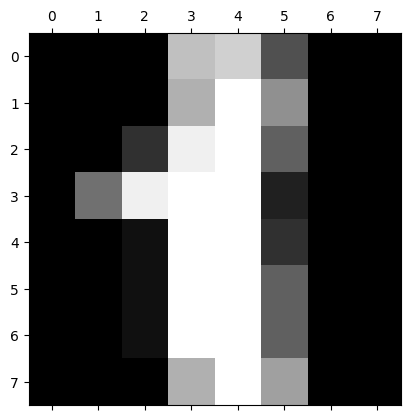

<Figure size 640x480 with 0 Axes>

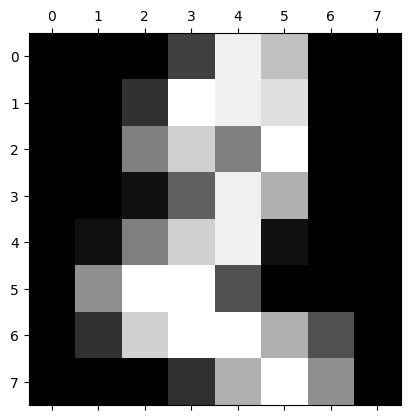

<Figure size 640x480 with 0 Axes>

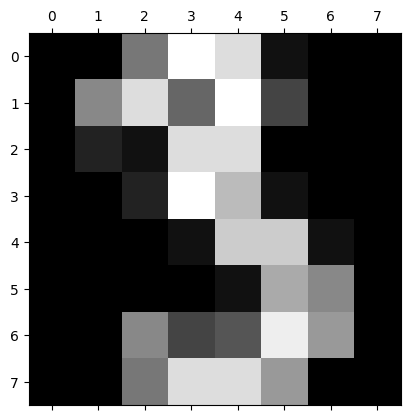

<Figure size 640x480 with 0 Axes>

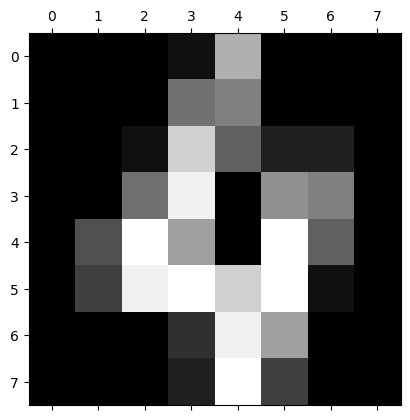

In [12]:



for x in range(5):
  plt.gray()
  plt.matshow(dataset.data[x].reshape(8,8))
  plt.show()

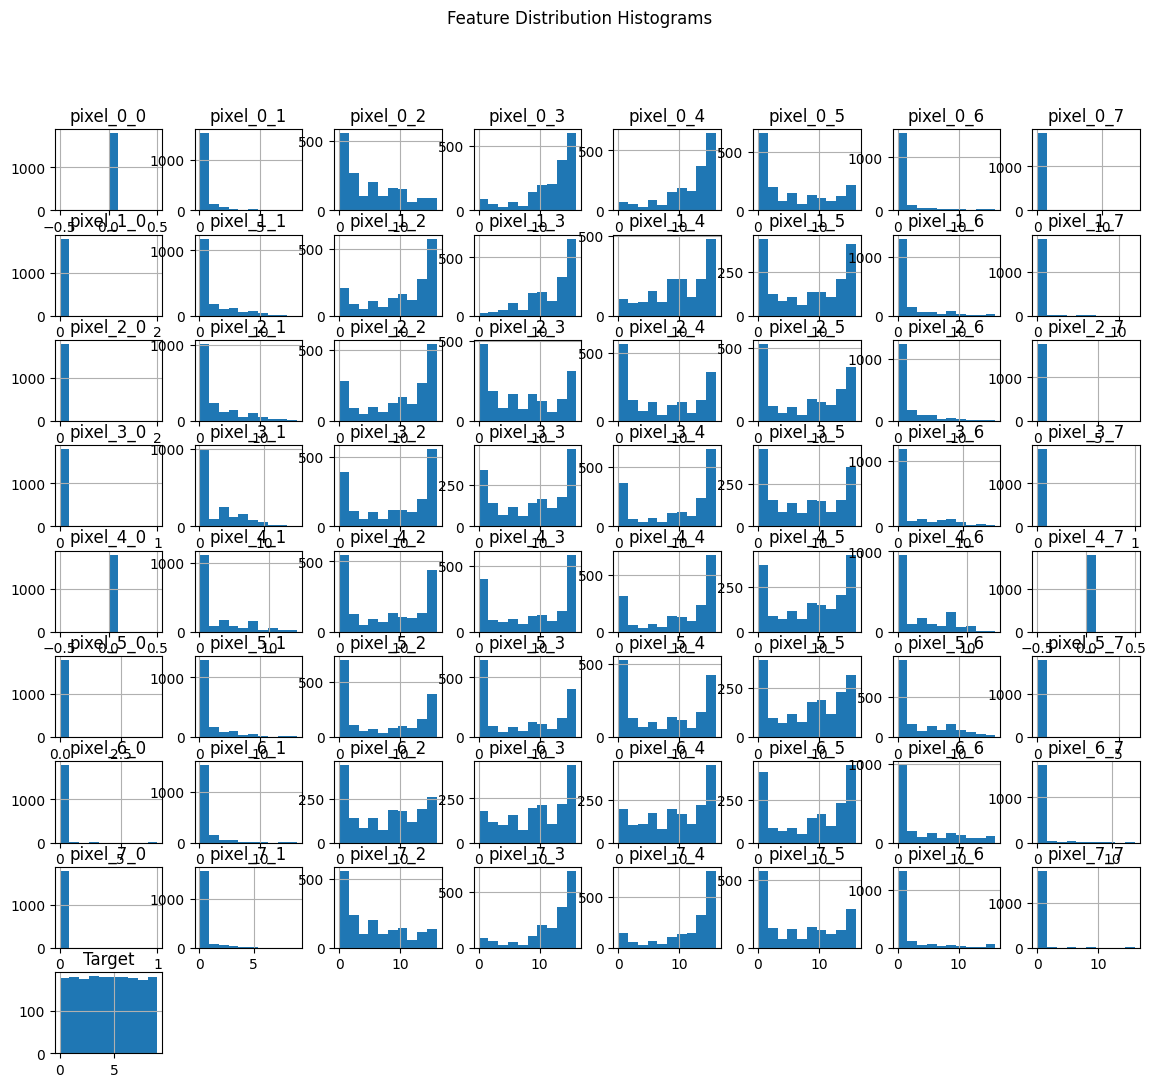

In [51]:
df.hist(figsize=(14,12))

plt.suptitle("Feature Distribution Histograms")

plt.show()

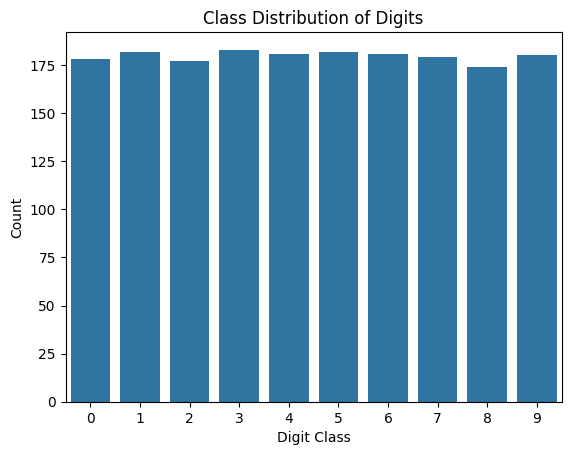

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=dataset.target)

plt.title("Class Distribution of Digits")
plt.xlabel("Digit Class")
plt.ylabel("Count")

plt.show()

## ⚙️ Solution Approach

The project follows a complete Machine Learning workflow for handwritten digit classification.

1. Data Loading
   The digits dataset was loaded using Scikit-learn’s built-in dataset module.

2. Exploratory Data Analysis (EDA)
   EDA techniques and visualizations were used to understand feature distributions, class balance, and dataset structure.

3. Data Preprocessing
   The dataset was standardized using StandardScaler to normalize feature values before applying dimensionality reduction.

4. Dimensionality Reduction using LDA
   Linear Discriminant Analysis (LDA) was applied to reduce feature dimensions while maximizing class separability.

5. Model Training
   A Logistic Regression classifier was trained on the LDA-transformed dataset.

6. Model Evaluation
   The model performance was evaluated using accuracy score, confusion matrix, and classification metrics.


In [13]:
# Divide the data into X nd Y
# Then perform train test split

In [14]:
X = dataset.data
Y = dataset.target

In [15]:
X # independent features

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [16]:
Y # Dependent features

array([0, 1, 2, ..., 8, 9, 8])

In [17]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [18]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.20,random_state=3)

In [19]:
x_train.shape

(1437, 64)

In [20]:
x_test.shape

(360, 64)

In [21]:
y_train.shape

(1437,)

In [22]:
y_test.shape

(360,)

Equal contribution of features: LDA works by finding linear combination of features that best seperate the classes.

What if the features have different scales or units (eg: age in years vs income in dollars), those with larger values or variances will dominate the calculation leading to biased results.

Standardiaztion ensures that each feature contibutes equally to the analysis. Standardization can improve the stability and performance of the lda algorithm, especially in high dimensional columns where some features may dominate others.


In [23]:
sc =StandardScaler()

In [24]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [25]:
# fit_transfrom on x_train
# fit => find the mean and standard deviation from x_train
# transform => uses these values to scale x_train
# transfrom on x_test
# we do not use fit on x_test because we dont want to recalculate the mean and std.
# we use the mean and std of x_train that is stored in the object of standard scaler 'sc'


In [26]:
x_test.std()

np.float64(0.9489205159243688)

In [27]:
x_train.std()

np.float64(0.9762812094883326)

In [28]:
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,-0.332769,-0.241767,0.977815,0.976815,0.398811,-0.407540,-0.121535,-0.061417,-0.616625,...,-0.766521,-0.220588,-0.026389,-0.303466,0.098887,-0.026314,0.014679,-0.836130,-0.517331,-0.200105
1,0.0,-0.332769,-1.080439,-1.868958,0.506806,1.461074,-0.101885,-0.121535,-0.061417,-0.616625,...,-0.157963,-0.220588,-0.026389,-0.303466,-1.075498,-2.317994,0.841860,1.193463,-0.517331,-0.200105
2,0.0,-0.332769,-1.080439,0.028890,0.271801,-1.017540,-0.407540,-0.121535,-0.061417,-0.616625,...,-0.766521,-0.220588,-0.026389,-0.303466,-1.075498,-0.255482,0.221474,-1.174395,-0.517331,-0.200105
3,0.0,2.949996,1.435576,0.977815,-0.668218,-1.017540,-0.407540,-0.121535,-0.061417,3.455195,...,0.450596,0.850309,-0.026389,1.871500,1.860465,0.890358,0.841860,1.531728,3.333262,1.374078
4,0.0,-0.332769,1.016240,0.977815,-0.198209,-1.017540,-0.407540,-0.121535,-0.061417,1.889110,...,0.247743,-0.220588,-0.026389,-0.303466,1.273272,0.890358,0.841860,1.531728,3.092600,-0.200105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1432,0.0,-0.332769,-0.661103,0.503353,-0.433213,-1.017540,-0.407540,-0.121535,-0.061417,-0.616625,...,2.276272,-0.220588,-0.026389,-0.303466,-0.684037,-0.255482,0.841860,1.362595,0.685979,-0.200105
1433,0.0,-0.332769,1.016240,-0.682803,-2.783261,-1.017540,-0.407540,-0.121535,-0.061417,-0.616625,...,0.450596,4.063002,-0.026389,-0.303466,0.294618,0.890358,0.841860,1.531728,3.333262,7.146081
1434,0.0,-0.332769,0.596904,0.028890,0.036796,-0.840496,-0.407540,-0.121535,-0.061417,0.323025,...,0.450596,-0.220588,-0.026389,-0.303466,-0.096844,0.202854,-0.192117,-0.497865,-0.517331,-0.200105
1435,0.0,1.855741,1.645244,0.977815,0.976815,0.752899,-0.407540,-0.121535,19.550963,4.081629,...,0.856302,0.850309,-0.026389,1.871500,1.860465,0.890358,0.841860,0.855197,2.370614,0.324623


In [29]:
# selecting n components?


# LDA?

Inorder to find the number of components required for LDA, we can use a simple formula of min(number_of_features, numer_of_classes-1)

In [30]:
n = df['Target'].nunique()

In [31]:
n

10

In [32]:
LDA = LinearDiscriminantAnalysis(n_components=9)

In [33]:
x_train = LDA.fit_transform(x_train,y_train)
x_test = LDA.transform(x_test)

In [34]:
x_train.shape

(1437, 9)

In [35]:
x_test.shape

(360, 9)

In [36]:
x_train

array([[ 1.38069400e+00,  3.69322869e+00, -7.50533084e-04, ...,
        -1.69716721e+00,  1.56404454e+00,  1.08422391e+00],
       [ 1.22537771e-01,  1.85175403e-01, -3.80326106e-01, ...,
         3.67854881e-01,  2.64235458e-01, -8.87346964e-01],
       [-3.69864209e+00,  3.41921442e+00, -1.84203801e+00, ...,
        -1.93185614e-01, -6.05515487e-01, -2.10210719e+00],
       ...,
       [-1.74781390e+00, -5.46881874e+00,  9.67485153e-01, ...,
        -7.32444415e-01,  2.29199343e-01,  3.62899827e-01],
       [ 5.14952752e+00,  1.51783836e+00,  2.19343116e+00, ...,
        -8.15108163e-01, -3.41917064e+00,  1.39048702e+00],
       [ 3.59214703e-02,  1.62448790e+00,  2.64868425e+00, ...,
        -1.76854884e+00,  3.85762784e-02, -1.88173469e-01]])

In [37]:
y_train

array([1, 8, 4, ..., 0, 2, 1])

In [38]:
x_test

array([[-2.93601607, -5.79376782,  1.88191796, ..., -0.74540738,
         1.5292421 ,  0.3911555 ],
       [-4.49451715,  2.27125071, -0.72978417, ...,  0.13959436,
        -0.93377526, -0.88588519],
       [ 0.94823418,  4.23610415,  1.80147914, ...,  0.30850421,
         1.38627661, -1.54153851],
       ...,
       [-4.170739  , -0.48294573,  2.87973163, ...,  0.18471687,
         0.58914392, -1.20190557],
       [ 2.66124297,  0.68611693,  2.59908129, ..., -0.42593727,
         0.46373566,  1.50400186],
       [-2.91557243, -5.02234497,  0.44720517, ..., -1.48889061,
         0.98892687,  0.49405564]])

In [39]:
y_test

array([0, 4, 1, 2, 0, 0, 8, 7, 6, 6, 3, 6, 9, 7, 4, 7, 4, 3, 2, 6, 4, 3,
       4, 7, 1, 0, 7, 4, 8, 3, 4, 0, 5, 5, 5, 1, 2, 9, 0, 0, 0, 8, 2, 3,
       7, 0, 1, 7, 1, 3, 8, 4, 2, 9, 6, 0, 4, 5, 4, 4, 7, 9, 9, 5, 0, 3,
       7, 4, 9, 1, 8, 0, 9, 3, 0, 2, 7, 8, 1, 6, 9, 3, 3, 2, 2, 3, 8, 2,
       4, 6, 9, 5, 8, 4, 7, 3, 7, 2, 5, 6, 5, 6, 1, 0, 6, 4, 8, 1, 5, 6,
       8, 8, 8, 6, 4, 0, 2, 7, 5, 0, 8, 5, 8, 4, 7, 0, 5, 9, 0, 1, 8, 4,
       7, 9, 6, 1, 2, 7, 1, 3, 5, 3, 5, 2, 7, 4, 9, 2, 0, 0, 9, 2, 8, 4,
       0, 9, 7, 0, 1, 4, 1, 8, 0, 7, 9, 1, 9, 7, 2, 7, 7, 0, 5, 3, 4, 0,
       5, 2, 3, 0, 3, 0, 1, 9, 5, 4, 8, 2, 6, 0, 9, 7, 8, 8, 7, 3, 0, 9,
       5, 3, 6, 3, 7, 9, 0, 5, 7, 6, 5, 3, 1, 0, 4, 3, 1, 0, 5, 3, 7, 3,
       2, 3, 5, 0, 7, 4, 5, 3, 0, 0, 5, 7, 5, 2, 4, 2, 9, 3, 3, 0, 9, 3,
       1, 3, 1, 7, 4, 7, 4, 5, 2, 1, 1, 4, 7, 1, 7, 5, 2, 5, 2, 5, 0, 9,
       2, 0, 7, 6, 5, 4, 9, 1, 4, 1, 8, 0, 7, 4, 7, 1, 3, 4, 9, 5, 0, 3,
       0, 5, 4, 3, 6, 1, 4, 3, 8, 5, 2, 7, 4, 6, 4,

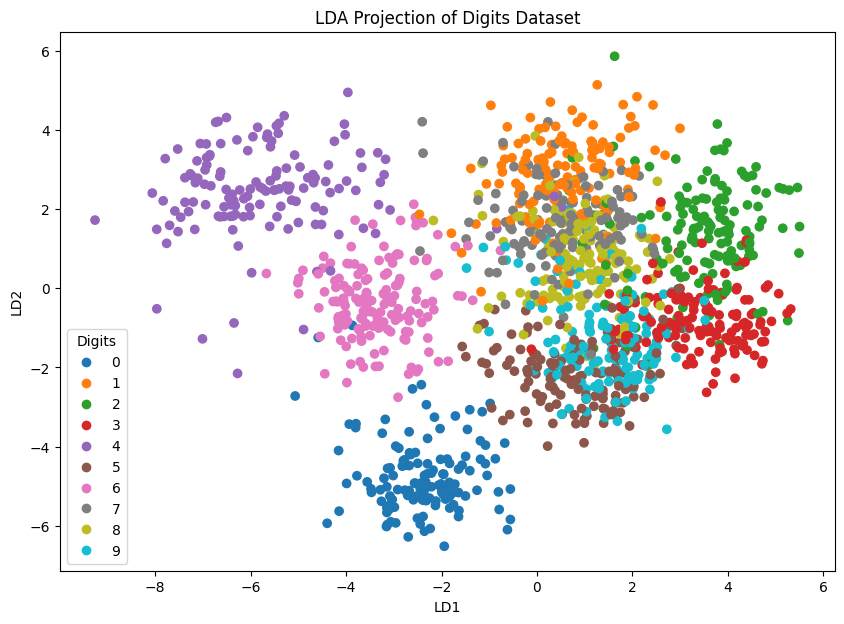

In [53]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train,
    cmap='tab10'
)

plt.xlabel("LD1")
plt.ylabel("LD2")

plt.title("LDA Projection of Digits Dataset")

plt.legend(*scatter.legend_elements(),
           title="Digits")

plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
log_model = LogisticRegression()

In [42]:
log_model.fit(x_train,y_train)

LogisticRegression()

In [43]:
log_pred = log_model.predict(x_test)

In [55]:
acc=accuracy_score(y_test,log_pred)

In [56]:
acc

0.9444444444444444

In [45]:
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8
0,1.380694,3.693229,-0.000751,-0.574047,1.588643,-0.689992,-1.697167,1.564045,1.084224
1,0.122538,0.185175,-0.380326,1.472776,2.937911,0.539518,0.367855,0.264235,-0.887347
2,-3.698642,3.419214,-1.842038,-2.434612,1.096481,2.686419,-0.193186,-0.605515,-2.102107
3,4.131082,1.944365,2.557198,-0.552376,-4.545198,2.395255,1.289136,-1.232355,-0.645123
4,4.043168,1.600023,4.401218,-1.159915,-2.970289,1.748486,-1.036612,-2.304143,-0.311440
...,...,...,...,...,...,...,...,...,...
1432,-3.674116,0.508349,2.809358,2.618736,-1.699757,-2.249191,0.369945,-0.655297,-1.104074
1433,1.238322,2.227923,2.760529,0.963105,0.856491,2.038549,-1.404240,1.402759,0.310158
1434,-1.747814,-5.468819,0.967485,-2.937617,-1.968051,0.511081,-0.732444,0.229199,0.362900
1435,5.149528,1.517838,2.193431,-0.462409,-2.587385,-0.250257,-0.815108,-3.419171,1.390487


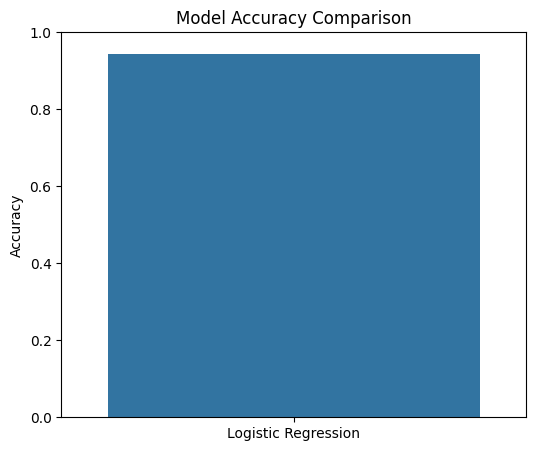

In [57]:
models = ['Logistic Regression']
scores = [acc]

plt.figure(figsize=(6,5))

sns.barplot(x=models,
            y=scores)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

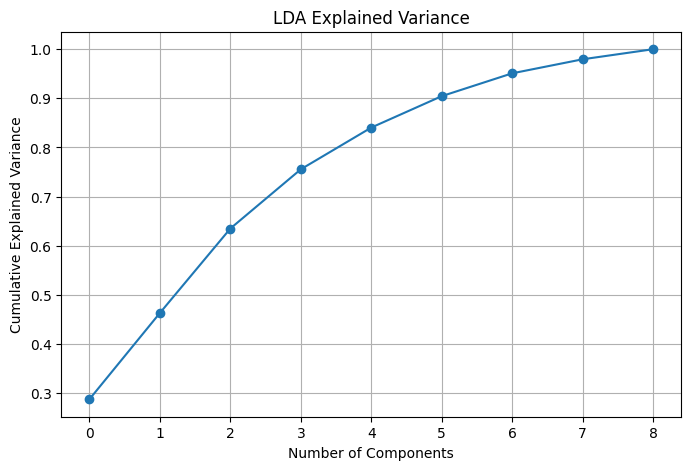

In [59]:
import numpy as np

explained_variance = LDA.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(explained_variance),
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("LDA Explained Variance")

plt.grid()

plt.show()

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       0.83      1.00      0.91        35
           2       1.00      0.97      0.98        31
           3       0.91      0.97      0.94        40
           4       1.00      0.86      0.93        44
           5       1.00      0.89      0.94        38
           6       0.96      0.96      0.96        25
           7       0.95      1.00      0.98        42
           8       0.89      0.83      0.86        29
           9       0.90      0.93      0.92        29

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.95      0.94      0.94       360



## 📈 Results and Conclusion

The Logistic Regression model achieved strong multiclass classification performance after applying Linear Discriminant Analysis (LDA). LDA successfully reduced the dimensionality of the dataset while preserving important class-discriminating information.

The project demonstrated that combining dimensionality reduction with classification algorithms can improve computational efficiency and maintain high prediction accuracy. Visualization techniques such as LDA projection plots and confusion matrices helped analyze class separation and model performance effectively.

This project highlights the importance of preprocessing, dimensionality reduction, and model evaluation in Machine Learning workflows for image classification tasks.
